In [1]:
import numpy as np
import pandas as pd
import os
import json
import systeme as sys
import Allocation
from simulation import simulation
import time

In [ ]:
def get_voisins(df:pd.DataFrame, line:int, col:int, system:sys.systeme):
    offset = sum([len(x.ressources) for x in system.cellules[:col]])+1
    arr = np.arange(offset,offset+len(system.cellules[col].ressources))
    voisins_locaux = np.delete(arr, np.where(arr == df.iloc[line, col])[0])
    voisins = []
    for voisin in voisins_locaux:
        df_copy = df.copy()
        df_copy.iloc[line, col] = voisin
        voisins.append(df_copy)
    return voisins

def get_echanges(df:pd.DataFrame, line:int, col:int):
    arr_solution = df.values
    valeur_courante = arr_solution[line, col]

    lignes_suivantes = np.arange(line + 1, arr_solution.shape[0])
    valeurs_suivantes = arr_solution[lignes_suivantes, col]

    mask_diff = valeurs_suivantes != valeur_courante
    lignes_differentes = lignes_suivantes[mask_diff]
    valeurs_differentes = valeurs_suivantes[mask_diff]

    if len(lignes_differentes) == 0:
        return []

    echanges_array = np.repeat(arr_solution[np.newaxis, :, :], len(lignes_differentes), axis=0)
    echanges_array[:, line, col] = valeurs_differentes
    echanges_array[np.arange(len(lignes_differentes)), lignes_differentes, col] = valeur_courante

    return [pd.DataFrame(echange, columns=df.columns) for echange in echanges_array]

def upgrade_insert(system:sys.systeme, scenario:pd.DataFrame, solution:pd.DataFrame, stats:dict, verbose:int):
    symetries_indices  = np.empty((solution.shape[0]*solution.shape[1]), dtype=object)
    symetries_indices[:] = [[] for _ in range(solution.shape[0] * solution.shape[1])]
    symetries_indices = symetries_indices.reshape(solution.shape[0], solution.shape[1])
    produit, cellule = 0,0
    upgraded = False
    old_mct = best_mct = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, solution) for _ in range(len(system.cellules))]).mean_completion_time()
    while cellule < solution.shape[1]:
        while produit < solution.shape[0]:
            reset = False
            solutions_generees = get_voisins(solution, line=produit, col=cellule, system=system)
            iteration = 0
            for voisin in solutions_generees:
                if verbose > 0:
                    print(f"\tline {produit+1}, col {cellule+1}/{solution.shape[1]}, iteration {iteration+1}/{len(solutions_generees)}                              ",end="\r")
                mct = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, voisin) for _ in range(len(system.cellules))]).mean_completion_time()
                if (mct == best_mct):
                    if verbose > 1:
                        print(f"\n\t\tsymetrie produit {produit+1} cell {cellule+1} solution originale {solution.iloc[produit, cellule]} avec solution {voisin.iloc[produit, cellule]}")
                    symetries_indices[produit, cellule].append(iteration)
                    if stats is not None:
                        stats["symetries"][1,cellule] += 1
                elif (mct < best_mct):
                    if verbose > 0:
                        print(f"new best solution found, from {best_mct} to {mct}, redo all")
                    if stats is not None:
                        stats["improvements"] +=1
                    best_mct = mct
                    solution = voisin
                    reset = True
                    upgraded = True
                    if stats is not None:
                        stats["symetries"] = np.zeros_like(stats["symetries"])
                    break
                iteration+=1
            if reset : 
                cellule, produit = 0, 0
                symetries_indices  = np.empty((solution.shape[0]*solution.shape[1]), dtype=object)
                symetries_indices[:] = [[] for _ in range(solution.shape[0] * solution.shape[1])]
                symetries_indices = symetries_indices.reshape(solution.shape[0], solution.shape[1])
            else :
                produit+=1
        cellule+=1
        produit = 0

    return solution, upgraded, old_mct, best_mct, symetries_indices

def upgrade_swap(system:sys.systeme, scenario:pd.DataFrame, solution:pd.DataFrame, stats:dict, verbose:int):
    symetries_indices  = np.empty((solution.shape[0]*solution.shape[1]), dtype=object)
    symetries_indices[:] = [[] for _ in range(solution.shape[0] * solution.shape[1])]
    symetries_indices = symetries_indices.reshape(solution.shape[0], solution.shape[1])
    produit, cellule = 0,0
    upgraded = False
    old_mct = best_mct = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, solution) for _ in range(len(system.cellules))]).mean_completion_time()
    while cellule < solution.shape[1]:
        while produit < solution.shape[0]:
            reset = False
            solutions_generees = get_echanges(solution, produit, cellule)
            iteration = 0
            for i in range(len(solutions_generees)):
                if verbose > 0:
                    print(f"\tline {produit+1}, col {cellule+1}/{solution.shape[1]}, iteration {iteration+1}/{len(solutions_generees)}                              ",end="\r")
                mct = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, solutions_generees[i]) for _ in range(len(system.cellules))]).mean_completion_time()
                if (mct == best_mct):
                    if verbose > 1:
                        print(f"\n\t\tsymetrie produit {produit+1} cell {cellule+1} solution originale {solution.iloc[produit, cellule]} avec solution {solutions_generees[i].iloc[produit, cellule]}")
                    symetries_indices[produit, cellule].append(iteration)
                    if stats is not None:
                        stats["symetries"][0,cellule] += 1
                elif (mct < best_mct):
                    if verbose > 0:
                        print(f"\n\t\tnew best solution found, from {best_mct} to {mct}, redo all\n")
                    if stats is not None:
                        stats["improvements"] +=1
                    best_mct = mct
                    solution = solutions_generees[i]
                    reset = True
                    upgraded = True
                    if stats is not None:
                        stats["symetries"] = np.zeros_like(stats["symetries"])
                    break
                iteration+=1

            if reset : 
                cellule, produit = 0, 0
                symetries_indices  = np.empty((solution.shape[0]*solution.shape[1]), dtype=object)
                symetries_indices[:] = [[] for _ in range(solution.shape[0] * solution.shape[1])]
                symetries_indices = symetries_indices.reshape(solution.shape[0], solution.shape[1])
            else :
                produit+=1
        cellule+=1
        produit = 0

    return solution, upgraded, old_mct, best_mct, symetries_indices

def alter_multilabel_dataset_symetries(system:sys.systeme, solution:pd.DataFrame, swapORinsert:int, multilabel_logs:pd.DataFrame, indices_symetrie:np.ndarray, verbose:int):
    for produit in range(indices_symetrie.shape[0]):
        for cellule in range(indices_symetrie.shape[1]):
            if swapORinsert == 0:
                solutions_generees = get_echanges(solution, produit, cellule)
            elif swapORinsert == 1:
                solutions_generees = get_voisins(solution, produit, cellule, system)
            for iteration,i in zip(indices_symetrie[produit,cellule], range(len(indices_symetrie[produit,cellule]))):
                if verbose >0:
                    print(f"\t\tline {produit+1}/{indices_symetrie.shape[0]}, col {cellule+1}/{indices_symetrie.shape[0]}, iteration {i+1}/{len(indices_symetrie[produit,cellule])}",end="\r")
                multilabel_logs[cellule].iloc[produit, solutions_generees[iteration].iloc[produit, cellule]-1 - sum([len(c.ressources) for c in system.cellules][:cellule])-len(system.cellules[cellule].ressources)] = 1  
    return multilabel_logs



In [6]:
verbose = 1
ds = "g3"
scenarios_path_prefixe = f"scenarios/{ds}/"
solutions_path_prefixe = f"solution/{ds}_best/"
upgraded_solutions_path_prefixe = f"solution/{ds}_upgraded/"

if ds.startswith("k"):
    fms = "3C7R5F"
elif ds.startswith("g"):
    fms = "5C14R5F"
with open(f'fms/{fms}.json', 'r') as json_file: #5C14R5F #3C7R5F
    dic = json.load(json_file)
system = sys.systeme(dic)

for scenario_path, solution_path in zip(sorted(os.listdir(scenarios_path_prefixe), key= lambda k : int(k[1:].split(".csv")[0])), sorted(os.listdir(solutions_path_prefixe), key= lambda k : int(k.split(".csv")[0].split("_s")[-1]))):
    #if int(scenario_path.split(".")[0][1:])<7:
    #    continue

    if verbose > 0:
        print(f"\nscenario : {scenario_path}")
    #initialisation de solution systeme et scenario
    solution = pd.read_csv(solutions_path_prefixe+solution_path, sep=";", index_col=None, header=None).iloc[:,1:-1]
    scenario = pd.DataFrame(np.nan_to_num(pd.read_csv(scenarios_path_prefixe+scenario_path,header=None, index_col=None, sep=";"), nan=0)).astype(int).iloc[:,:-1]
    reset = True
    start_time = time.time()
    while reset:
        solution, upgraded, old_mct, new_mct, symetries_indices_swap = upgrade_swap(system, scenario, solution, None, verbose)
        if verbose > 0:
            print(f"\n\n\tswap improved ? {upgraded} " + (f"from {old_mct} to {new_mct}" if upgraded else f" with {old_mct}"))
        solution, upgraded, old_mct, new_mct, symetries_indices_insert = upgrade_insert(system, scenario, solution, None, verbose)
        if verbose > 0:
            print(f"\n\n\tinsert improved ? {upgraded} " + (f"from {old_mct} to {new_mct}" if upgraded else f" with {old_mct}"))
        reset = upgraded
    # arrivés là on est surs d'avoir la meilleure solution non ameliorable dans solution, on sauvegarde la solution
    solution.insert(0, None, [f"P{i+1}" for i in range(len(solution))])
    solution[len(solution.columns)] = 0
    solution.to_csv(upgraded_solutions_path_prefixe+solution_path, sep=";", index=False, header=False)

    # symetries
    if verbose > 0:
        print(f"\n\t meilleure solution trouvée, début traitement symétries\n")
    base_logs = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, solution.iloc[:,1:-1]) for _ in range(len(system.cellules))], saving=True).get_logs()
    multilabel_logs = [pd.get_dummies(base_log, columns=[base_log.columns[-1]], drop_first=False, dtype=int) for base_log in base_logs]
    for cell_log, i in zip(multilabel_logs, range(len(multilabel_logs))): # solution opti locale sans symetries
        cell_log.to_csv(f"generated_data_sym/{ds}/none/multilabel_data_original_{scenario_path.split(".")[0]}_cell_{i + 1}.csv", sep=";", index=None)

    multilabel_logs = alter_multilabel_dataset_symetries(system, solution.iloc[:,1:-1], 0, multilabel_logs, symetries_indices_swap, verbose)
    for cell_log, i in zip(multilabel_logs, range(len(multilabel_logs))): # avec swap seul
        cell_log.to_csv(f"generated_data_sym/{ds}/swap/multilabel_data_swap_{scenario_path.split(".")[0]}_cell_{i + 1}.csv", sep=";", index=None)
    
    base_logs = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, solution.iloc[:,1:-1]) for _ in range(len(system.cellules))], saving=True).get_logs()
    multilabel_logs = [pd.get_dummies(base_log, columns=[base_log.columns[-1]], drop_first=False, dtype=int) for base_log in base_logs]
    multilabel_logs = alter_multilabel_dataset_symetries(system, solution.iloc[:,1:-1], 1, multilabel_logs, symetries_indices_insert, verbose)  
    for cell_log, i in zip(multilabel_logs, range(len(multilabel_logs))): # avec insert seul
        cell_log.to_csv(f"generated_data_sym/{ds}/insert/multilabel_data_insert_{scenario_path.split(".")[0]}_cell_{i + 1}.csv", sep=";", index=None)


scenario : s1.csv
	line 60, col 2/5, iteration 21/30                              
		new best solution found, from 286.49 to 286.45, redo all

	line 60, col 2/5, iteration 3/27                               
		new best solution found, from 286.45 to 286.42, redo all

	line 60, col 2/5, iteration 3/30                               
		new best solution found, from 286.42 to 286.39, redo all

	line 81, col 2/5, iteration 1/12                               
		new best solution found, from 286.39 to 286.38, redo all

	line 82, col 2/5, iteration 1/11                               
		new best solution found, from 286.38 to 286.36, redo all

	line 82, col 2/5, iteration 4/14                               
		new best solution found, from 286.36 to 286.32, redo all

	line 7, col 3/5, iteration 52/80                               
		new best solution found, from 286.32 to 286.28, redo all

	line 22, col 3/5, iteration 24/68                              
		new best solution found, from 286.28 to

Symetries des machines identiques

In [7]:
# R1 et R2 dans la meme cellule  ---
# R1 tps setup R2 tps setup   ---
# R1 tps process R2 tps process  ---
# R1 pred_fam == R2 pred_fam 
# R1 current charge == R2 current charge


# 1 localliser les ressources identiques dans systeme pour chaque cellule
ds = "g3"
data_path_prefixe = f"generated_data_sym/{ds}/none/"
data_path_save = f"generated_data_sym/{ds}/machine_id/"
if ds.startswith("k"):
    fms = "3C7R5F"
elif ds.startswith("g"):
    fms = "5C14R5F"
with open(f'fms/{fms}.json', 'r') as json_file: #5C14R5F #3C7R5F
    dic = json.load(json_file)
system = sys.systeme(dic)
nb_symetries = {}
nb_cells = len(system.cellules)
identiques = []
for c in system.cellules:
    ids_cell = []
    for r in c.ressources:
        ids_ress = []
        for r2 in c.ressources:
            if r is r2 or (r.processTimes == r2.processTimes and r.setupTimes == r2.setupTimes) :
                ids_ress.append(True)
            else :
                ids_ress.append(False)
        ids_cell.append(ids_ress)
    identiques.append(ids_cell)
identical_couples = [[(i+1, j+1) for i, j in np.argwhere((np.array(idd).astype(int) == 1) & np.triu(np.ones(np.array(idd).astype(int).shape, dtype=bool), k=1))] for idd in identiques]
cell_containing_identities = np.where(np.array([int(np.sum(x)/len(x)) for x in identiques]) != 1)[0]

# 2 pour chaque dataset d'un scenario et d'une cellule contenant des identités
for dataset_path in os.listdir(data_path_prefixe):
    if dataset_path.endswith("json"):
        continue
    print(f"\nscenario {dataset_path.split("_cell")[0].split("_s")[-1]} :")
    cell = int(dataset_path[:-4].split("_")[-1]) -1

    nb_symetries[f"s{dataset_path.split("_cell")[0].split("_s")[-1]}.csv"] = nb_symetries.get(f"s{dataset_path.split("_cell")[0].split("_s")[-1]}.csv", [0]*nb_cells)
    if cell in cell_containing_identities:
        print(f"\tcellule {cell} :")
        dataset = pd.read_csv(data_path_prefixe+dataset_path, sep=";", index_col=None)
        
        # 3 trouver les colonnes a verifier
        for line in range(dataset.shape[0]):
            for couple in identical_couples[cell]:
                # 4 verifier les conditions
                if dataset["predFamilies_R"+str(couple[0])][line] == dataset["predFamilies_R"+str(couple[1])][line]  and  dataset["Cur_Charge_R"+str(couple[0])][line] == dataset["Cur_Charge_R"+str(couple[1])][line] \
                and  ((dataset[f"Selected Resource_{couple[0]-1}.0"][line] + dataset[f"Selected Resource_{couple[1]-1}.0"][line]) == 1):
                    print("\t\tsymetrie ligne : ", line)
                    nb_symetries[f"s{dataset_path.split("_cell")[0].split("_s")[-1]}.csv"][cell] += 1
                    # 5 succes, symetrie detectee rajouter les annotations
                    dataset.loc[line, f"Selected Resource_{couple[0]-1}.0"] = 1
                    dataset.loc[line, f"Selected Resource_{couple[1]-1}.0"] = 1

        # 6 sauvegarder le dataframe
        dataset.to_csv(data_path_save+dataset_path, sep=";", index=None)

#   2   3   4   3   2



scenario 10 :
	cellule 0 :
		symetrie ligne :  0

scenario 10 :

scenario 10 :

scenario 10 :
	cellule 3 :
		symetrie ligne :  99

scenario 10 :

scenario 11 :
	cellule 0 :
		symetrie ligne :  0

scenario 11 :

scenario 11 :

scenario 11 :
	cellule 3 :
		symetrie ligne :  97
		symetrie ligne :  98

scenario 11 :

scenario 12 :
	cellule 0 :
		symetrie ligne :  0

scenario 12 :

scenario 12 :

scenario 12 :
	cellule 3 :
		symetrie ligne :  95
		symetrie ligne :  97
		symetrie ligne :  97
		symetrie ligne :  99
		symetrie ligne :  99

scenario 12 :

scenario 13 :
	cellule 0 :
		symetrie ligne :  0

scenario 13 :

scenario 13 :

scenario 13 :
	cellule 3 :
		symetrie ligne :  93

scenario 13 :

scenario 14 :
	cellule 0 :
		symetrie ligne :  0

scenario 14 :

scenario 14 :

scenario 14 :
	cellule 3 :
		symetrie ligne :  96
		symetrie ligne :  97
		symetrie ligne :  98
		symetrie ligne :  99

scenario 14 :

scenario 15 :
	cellule 0 :
		symetrie ligne :  0

scenario 15 :

scenario 15 :

scena

In [ ]:
nb_cells = 5
syms_swap, syms_insert, syms_machid, swap_insert_and, swap_machid_and, insert_machid_and, all_and = [0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]
total_lignes = 0
instance_name = "g2"
for org_filename in os.listdir(f"generated_data_sym/{instance_name}/none/"):
    cell = int(org_filename.split("_")[-1][0])-1
    scenario_cell = "_".join(org_filename.split("_")[3:])
    swap_filename = [filename for filename in os.listdir(f"generated_data_sym/{instance_name}/swap/") if filename.endswith(scenario_cell)][0]
    insert_filename = [filename for filename in os.listdir(f"generated_data_sym/{instance_name}/insert/") if filename.endswith(scenario_cell)][0]
    machid_filenames = [filename for filename in os.listdir(f"generated_data_sym/{instance_name}/machine_id/") if filename.endswith(scenario_cell)]
    machid_filename = None
    if len(machid_filenames)>0:
        machid_filename = machid_filenames[0]

    dataset = pd.read_csv(f"generated_data_sym/{instance_name}/none/"+org_filename, sep=";", index_col=None)
    single_labels = dataset[[col for col in dataset.columns if col.startswith("Selected")]].to_numpy()

    dataset = pd.read_csv(f"generated_data_sym/{instance_name}/swap/"+swap_filename, sep=";", index_col=None)
    swap_labels = dataset[[col for col in dataset.columns if col.startswith("Selected")]].to_numpy()

    dataset = pd.read_csv(f"generated_data_sym/{instance_name}/insert/"+insert_filename, sep=";", index_col=None)
    insert_labels = dataset[[col for col in dataset.columns if col.startswith("Selected")]].to_numpy()

    if machid_filename is not None:
        dataset = pd.read_csv(f"generated_data_sym/{instance_name}/machine_id/"+machid_filename, sep=";", index_col=None)
        machid_labels = dataset[[col for col in dataset.columns if col.startswith("Selected")]].to_numpy()
    else:
        machid_labels = single_labels.copy()

    syms_swap[cell] += np.sum(swap_labels - single_labels)
    syms_insert[cell] += np.sum(insert_labels - single_labels)
    syms_machid[cell] += np.sum(machid_labels - single_labels)
    swap_insert_and[cell] += np.sum(((swap_labels + insert_labels - single_labels - single_labels) == 2))
    swap_machid_and[cell] += np.sum(((swap_labels + machid_labels - single_labels - single_labels) == 2))
    insert_machid_and[cell] += np.sum(((insert_labels + machid_labels - single_labels - single_labels) == 2))
    all_and[cell] += np.sum(((swap_labels + insert_labels + machid_labels - single_labels - single_labels - single_labels) == 3))
    total_lignes+= single_labels.shape[0]

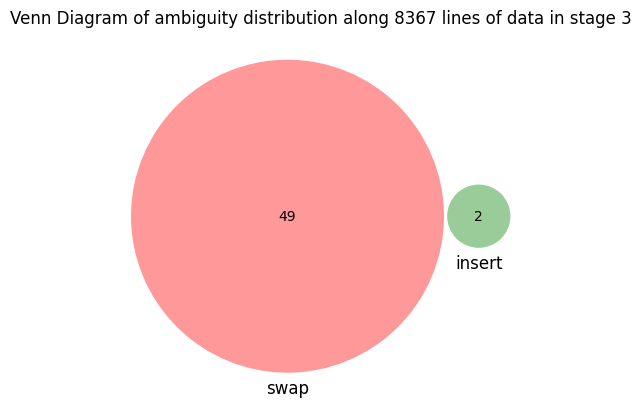

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

cell = 4
venn = venn3(subsets=(syms_swap[cell] - swap_insert_and[cell] - swap_machid_and[cell] + all_and[cell],  # swap only
              syms_insert[cell] - swap_insert_and[cell] - insert_machid_and[cell] + all_and[cell],  # insert only
              swap_insert_and[cell] - all_and[cell],  # swap && insert only
              syms_machid[cell] - swap_machid_and[cell] - insert_machid_and[cell] + all_and[cell],  # machines identiques only
              swap_machid_and[cell] - all_and[cell],  # swap && machines identiques only
              insert_machid_and[cell] - all_and[cell],  # insert && machines identiques only
              all_and[cell]), set_labels=("swap" if syms_swap[cell]>0 else "", "insert" if syms_insert[cell]>0 else "", "identical machines" if syms_machid[cell]>0 else ""))
plt.title(f"Venn Diagram of equivalent solutions distribution along {total_lignes} lines of data in stage {cell+1}")
plt.show()